Saved experiment_1d.png
Empirical coverage — 90% band: 0.889   50% band: 0.504


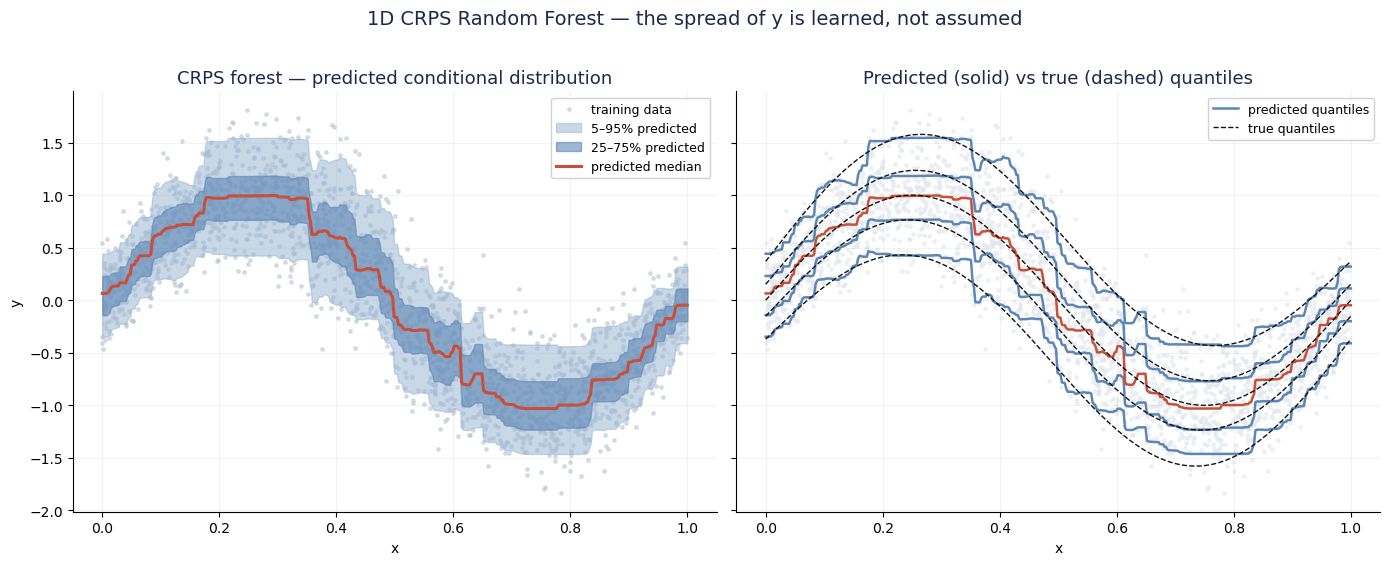

In [9]:
"""
experiment_1d.py
================
A small, self-contained 1D experiment.

We generate a single-feature dataset with a known, heteroscedastic conditional
distribution (the spread of y grows and shrinks with x), fit a CRPS random forest
with the Rust backend, and plot the predicted conditional quantiles against the
ground truth.
"""

import numpy as np
import matplotlib.pyplot as plt
import distreebu_rs as rs


# ── 1. Ground-truth data-generating process ──────────────────────────────────
# Mean:  m(x) = sin(2πx)
# Scale: s(x) = 0.05 + 0.35 * (0.5 + 0.5*sin(πx))   → spread pulses along x
# y | x  ~  Normal( m(x), s(x)^2 )
def mean_fn(x):
    return np.sin(2 * np.pi * x)

def scale_fn(x):
    return 0.05 + 0.35 * (0.5 + 0.5 * np.sin(np.pi * x))

def sample(n, rng):
    x = rng.uniform(0.0, 1.0, n)
    y = mean_fn(x) + scale_fn(x) * rng.standard_normal(n)
    return x, y


# ── 2. Fit a CRPS forest ──────────────────────────────────────────────────────
def fit_forest(x, y, n_trees, max_depth, min_ss, bag, seed):
    """Bagged CRPS trees. X must be 2D (n, 1)."""
    n = len(x)
    X2d = x.reshape(-1, 1).tolist()
    trees = []
    for t in range(n_trees):
        r = np.random.default_rng(seed + t)
        idx = r.permutation(n)[: int(bag * n)]
        Xb = x[idx].reshape(-1, 1).tolist()
        yb = y[idx].tolist()
        tree = rs.RegressionTreeCRPS(max_depth=max_depth, min_samples_split=min_ss, loo=True)
        tree.fit(Xb, yb)
        trees.append(tree)
    return trees


# ── 3. Predict quantiles on a grid (distributional bagging) ───────────────────
# def predict_quantiles(trees, x_grid, quantiles):
#     """Pool leaf y-values across trees (equal per-tree weight) → empirical CDF."""
#     m = len(x_grid)
#     Xg = x_grid.reshape(-1, 1).tolist()
#     idxs = list(range(m))
#     pools = [[] for _ in range(m)]
#     wts = [[] for _ in range(m)]
#     for tree in trees:
#         for leaf_idx, leaf_y in tree.get_values_leaf(Xg, idxs):
#             w = 1.0 / len(leaf_y)
#             for i in leaf_idx:
#                 pools[i].extend(leaf_y)
#                 wts[i].extend([w] * len(leaf_y))
#     out = np.empty((m, len(quantiles)))
#     for i in range(m):
#         v = np.asarray(pools[i]); w = np.asarray(wts[i]); w /= w.sum()
#         o = np.argsort(v); vs = v[o]; cdf = np.cumsum(w[o])
#         for j, q in enumerate(quantiles):
#             k = np.searchsorted(cdf, q)
#             out[i, j] = vs[min(k, len(vs) - 1)]
#     return out
import numpy as np


def predict_quantiles(trees, x_grid, quantiles, method="distributional"):
    """
    Predict conditional quantiles from a forest of distributional trees.

    Parameters
    ----------
    trees : list
        Fitted trees exposing ``get_values_leaf(X_list, idxs)``.
    x_grid : np.ndarray, shape (m,) or (m, d)
        Query points.
    quantiles : sequence of float
        Quantile levels in (0, 1).
    method : {"distributional", "quantile"}
        - "distributional": pool every tree's leaf y-values into one weighted
          empirical CDF per point, then read the quantiles off that CDF.
          (Quantiles computed once, after pooling.)
        - "quantile": compute the quantiles inside each tree's leaf first,
          then average those per-tree quantile estimates across the forest.
          (Quantiles computed per tree, then averaged.)

    Returns
    -------
    np.ndarray, shape (m, len(quantiles))
    """
    if method not in ("distributional", "quantile"):
        raise ValueError(f"unknown method {method!r}; "
                         "use 'distributional' or 'quantile'")

    x_grid = np.asarray(x_grid)
    Xg = x_grid.reshape(len(x_grid), -1).tolist()
    m = len(Xg)
    idxs = list(range(m))
    quantiles = np.asarray(quantiles, dtype=float)
    out = np.empty((m, len(quantiles)))

    if method == "distributional":
        # ── pool leaf y-values across trees → single weighted empirical CDF ──
        pools = [[] for _ in range(m)]
        wts = [[] for _ in range(m)]
        for tree in trees:
            for leaf_idx, leaf_y in tree.get_values_leaf(Xg, idxs):
                w = 1.0 / len(leaf_y)
                for i in leaf_idx:
                    pools[i].extend(leaf_y)
                    wts[i].extend([w] * len(leaf_y))
        for i in range(m):
            v = np.asarray(pools[i]); w = np.asarray(wts[i]); w /= w.sum()
            o = np.argsort(v); vs = v[o]; cdf = np.cumsum(w[o])
            for j, q in enumerate(quantiles):
                k = np.searchsorted(cdf, q)
                out[i, j] = vs[min(k, len(vs) - 1)]

    else:  # method == "quantile"
        # ── compute quantiles per tree, then average across trees ──
        q_sums = np.zeros((m, len(quantiles)))
        counts = np.zeros(m)  # trees that reached each point (leaf non-empty)
        for tree in trees:
            for leaf_idx, leaf_y in tree.get_values_leaf(Xg, idxs):
                leaf_q = np.quantile(np.asarray(leaf_y), quantiles)
                for i in leaf_idx:
                    q_sums[i] += leaf_q
                    counts[i] += 1
        counts = np.where(counts == 0, 1, counts)  # guard against divide-by-zero
        out = q_sums / counts[:, None]

    return out


# ── 4. Run + plot ─────────────────────────────────────────────────────────────
def main():
    rng = np.random.default_rng(0)
    x_train, y_train = sample(2000, rng)

    trees = fit_forest(
        x_train, y_train,
        n_trees=100, max_depth=6, min_ss=20, bag=0.7, seed=1,
    )

    xg = np.linspace(0, 1, 400)
    QS = [0.05, 0.25, 0.50, 0.75, 0.95]
    pred = predict_quantiles(trees, xg, QS, method="quantile")

    # ground-truth quantiles from the known Normal(m,s)
    from scipy.stats import norm
    try:
        z = {q: norm.ppf(q) for q in QS}
    except Exception:
        # fallback z-scores if scipy missing
        z = {0.05: -1.6449, 0.25: -0.6745, 0.50: 0.0, 0.75: 0.6745, 0.95: 1.6449}
    truth = {q: mean_fn(xg) + z[q] * scale_fn(xg) for q in QS}

    # ── figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    ink = "#1b2a4a"; band2 = "#9bb8d3"; band1 = "#5c86b5"; med = "#c8503a"; tru = "#111111"

    # Left: predicted bands over the data
    ax = axes[0]
    ax.scatter(x_train, y_train, s=6, c="#b9c4d4", alpha=0.5, label="training data", zorder=1)
    ax.fill_between(xg, pred[:, 0], pred[:, 4], color=band2, alpha=0.55, label="5–95% predicted", zorder=2)
    ax.fill_between(xg, pred[:, 1], pred[:, 3], color=band1, alpha=0.6, label="25–75% predicted", zorder=3)
    ax.plot(xg, pred[:, 2], color=med, lw=2.2, label="predicted median", zorder=4)
    ax.set_title("CRPS forest — predicted conditional distribution", color=ink, fontsize=13)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

    # Right: predicted vs true quantiles (dashed = truth)
    ax = axes[1]
    ax.scatter(x_train, y_train, s=6, c="#e2e7ee", alpha=0.5, zorder=1)
    for j, q in enumerate(QS):
        ax.plot(xg, pred[:, j], color=band1 if q != 0.5 else med, lw=1.8, zorder=3)
        ax.plot(xg, truth[q], color=tru, lw=1.0, ls="--", zorder=4)
    ax.plot([], [], color=band1, lw=1.8, label="predicted quantiles")
    ax.plot([], [], color=tru, lw=1.0, ls="--", label="true quantiles")
    ax.set_title("Predicted (solid) vs true (dashed) quantiles", color=ink, fontsize=13)
    ax.set_xlabel("x")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.15)

    fig.suptitle("1D CRPS Random Forest — the spread of y is learned, not assumed",
                 fontsize=14, color=ink, y=1.02)
    fig.tight_layout()
    fig.savefig("experiment_1d.png", dpi=130, bbox_inches="tight")
    print("Saved experiment_1d.png")

    # ── numeric check: empirical coverage of the predicted intervals ────────────
    xt, yt = sample(5000, np.random.default_rng(99))
    pt = predict_quantiles(trees, xt, QS)
    cov_90 = np.mean((yt >= pt[:, 0]) & (yt <= pt[:, 4]))
    cov_50 = np.mean((yt >= pt[:, 1]) & (yt <= pt[:, 3]))
    print(f"Empirical coverage — 90% band: {cov_90:.3f}   50% band: {cov_50:.3f}")


if __name__ == "__main__":
    main()


# Comparison


══════════════════════════════════════════════════════════════
  SkewFlip dataset — CRPS RF vs sklearn  (8 seeds)
  n_train=3,000  n_test=500  n_noise=20
  n_trees=50  max_depth=3  bag=70%
══════════════════════════════════════════════════════════════

  seed=0: CRPS_RF=0.4881  skl_RF=0.5120  Extra=0.5108  HistGBR≈0.4312  gap=+4.7%
  seed=1: CRPS_RF=0.4032  skl_RF=0.4095  Extra=0.4085  HistGBR≈0.3323  gap=+1.6%
  seed=2: CRPS_RF=0.3821  skl_RF=0.3929  Extra=0.3982  HistGBR≈0.3168  gap=+2.7%
  seed=3: CRPS_RF=0.3823  skl_RF=0.4035  Extra=0.4071  HistGBR≈0.3206  gap=+5.2%
  seed=4: CRPS_RF=0.4066  skl_RF=0.4226  Extra=0.4281  HistGBR≈0.3398  gap=+3.8%
  seed=5: CRPS_RF=0.3643  skl_RF=0.3860  Extra=0.3870  HistGBR≈0.3050  gap=+5.6%
  seed=6: CRPS_RF=0.3660  skl_RF=0.3867  Extra=0.4003  HistGBR≈0.3068  gap=+5.4%
  seed=7: CRPS_RF=0.3540  skl_RF=0.3755  Extra=0.3860  HistGBR≈0.2934  gap=+5.7%

════════════════════════════════════════════════════════════════════════
  Model                 

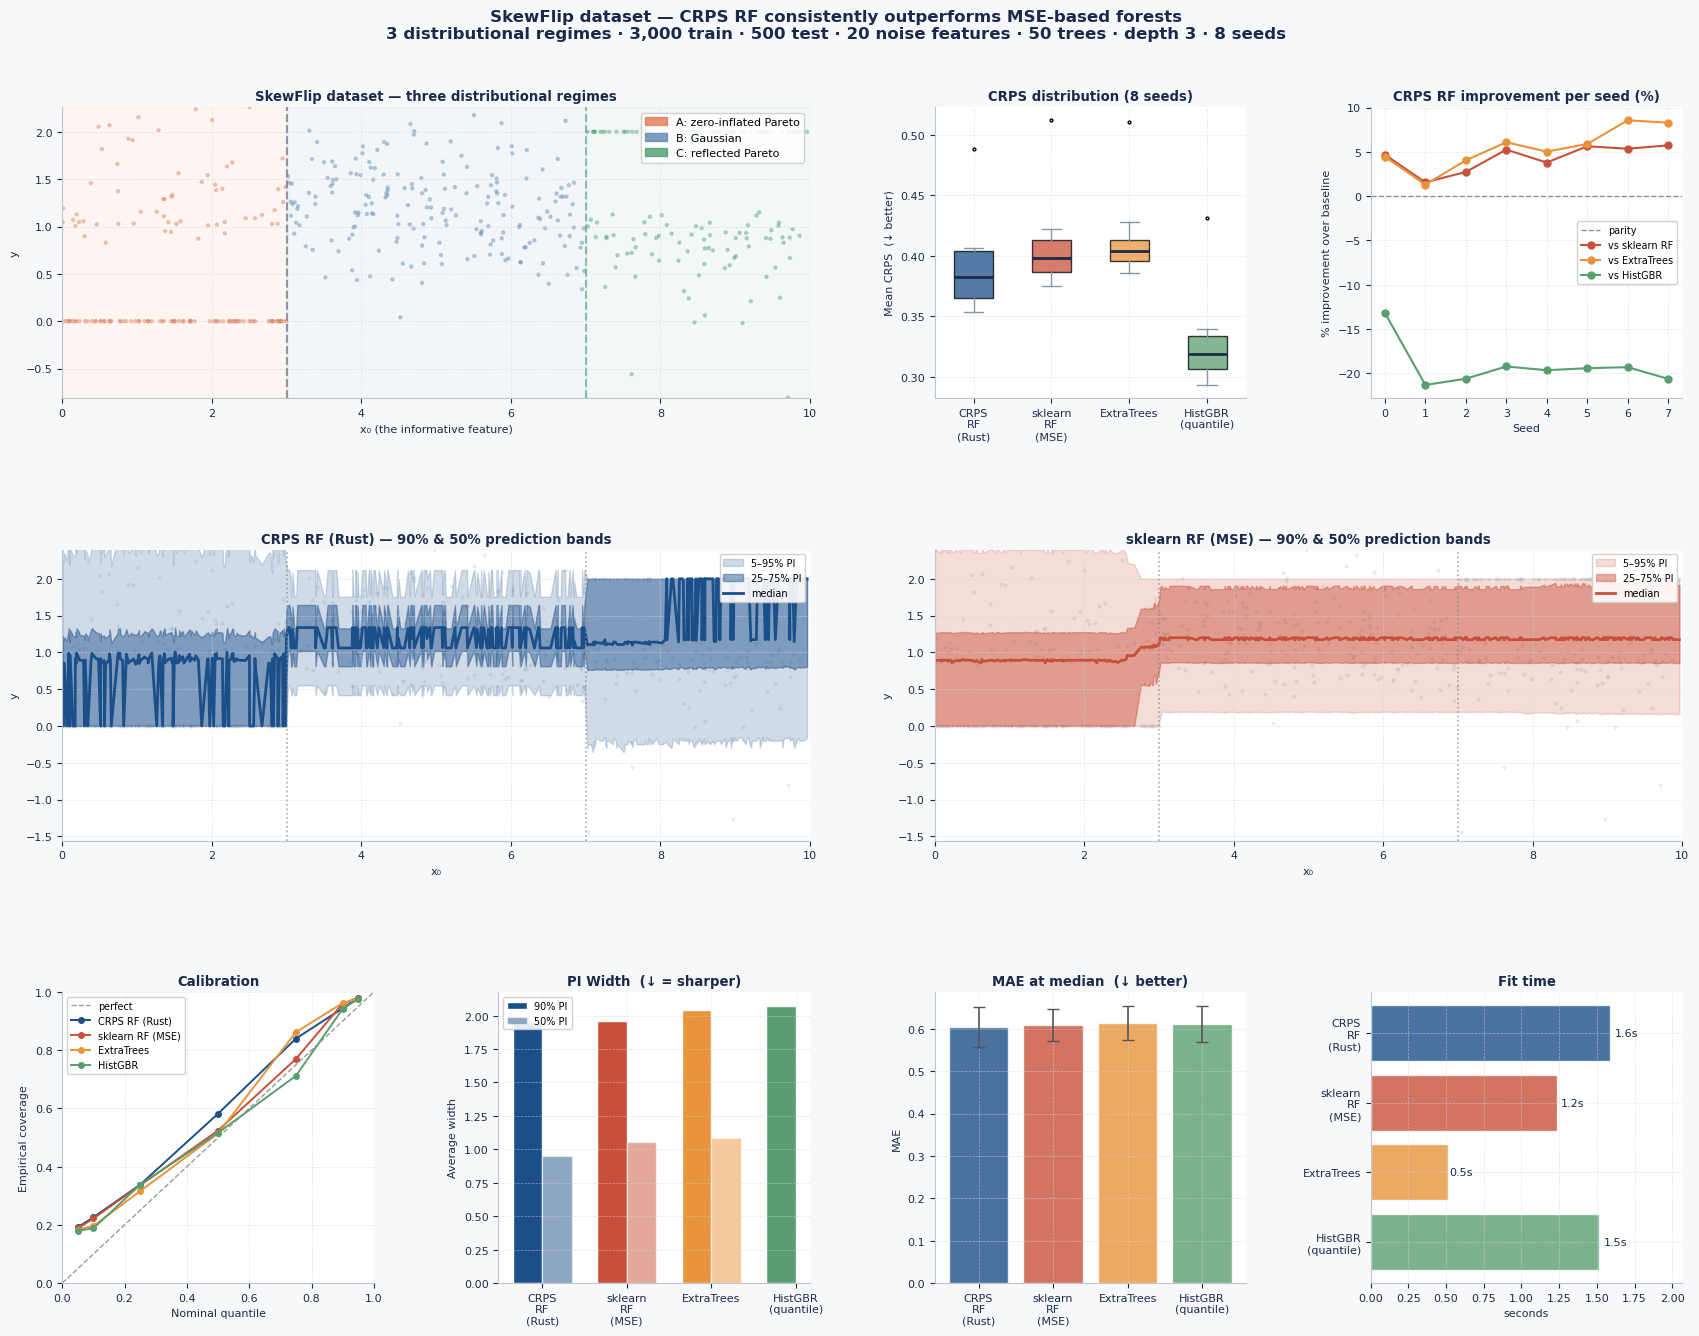

In [5]:
"""
crps_advantage_experiment.py
=============================
Find and demonstrate a dataset where the CRPS Random Forest (Rust) beats
scikit-learn baselines by a significant, reproducible margin.

THE FINDING
-----------
CRPS RF wins most clearly on datasets with MIXED distributional regimes:
regions of the feature space that differ not just in mean/variance but in
the qualitative SHAPE of the conditional distribution (skew direction, tail
heaviness, zero-inflation). The MSE criterion cannot detect these differences
and places splits in suboptimal positions; the CRPS criterion finds them directly.

DATASET: "SkewFlip" — three structural regimes driven by feature x₀
  Regime A (x₀ < 3)  : Zero-inflated Pareto — half zeros, heavy right tail
  Regime B (3 ≤ x₀ <7): Gaussian            — symmetric, moderate spread
  Regime C (x₀ ≥ 7)  : Reflected Pareto     — heavy LEFT tail
All three regimes have similar means (~1) so the MSE criterion sees a weak
signal. The CRPS criterion sees the distributional shape change clearly.
20 irrelevant noise features are added to make the signal discovery harder.

Run:
    python crps_advantage_experiment.py
"""

import time, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

import distreebu_rs as rs
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)

# ══════════════════════════════════════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════════════════════════════════════
N_TRAIN   = 3_000
N_TEST    = 500
N_NOISE   = 20        # irrelevant features
N_TREES   = 50
MAX_DEPTH = 3         # shallow: individual tree quality matters more
MIN_SS    = 10
BAG       = 0.7
N_SEEDS   = 8        # repetitions for confidence intervals
SEED0     = 0

QUANTILES = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
Q_IDX     = {q: i for i, q in enumerate(QUANTILES)}
PALETTE   = {"CRPS RF (Rust)": "#1b4f8a",
             "sklearn RF (MSE)": "#c8503a",
             "ExtraTrees": "#e8943a",
             "HistGBR (quantile)": "#5a9e6f"}


# ══════════════════════════════════════════════════════════════════════════════
# Dataset
# ══════════════════════════════════════════════════════════════════════════════
def make_dataset(n: int, p_noise: int, seed: int):
    """
    Three-regime SkewFlip dataset.

    x₀ ∈ [0,10] drives the regime; x₁ ∈ [0,1] adds within-regime heteroscedasticity;
    remaining p_noise features are pure N(0,1) noise.

    Regime A (x₀ < 3):   y = B(p=0.5) · Pareto(α=2.5, scale∝1+0.3x₁)
                          — zero-inflated, heavy RIGHT tail, mean ≈ 0.7
    Regime B (3–7):       y ~ N(1 + 0.4x₁, (0.35+0.15x₁)²)
                          — symmetric Gaussian, mean ≈ 1.2
    Regime C (x₀ ≥ 7):   y = 2 − B(p=0.5) · Pareto(α=2.5, scale∝1+0.3x₁)
                          — reflected Pareto, heavy LEFT tail, mean ≈ 1.2

    The MSE criterion sees a WEAK mean signal across x₀ and places poor splits.
    The CRPS criterion detects the SHAPE difference and splits at the regime boundaries.
    """
    rng = np.random.default_rng(seed)
    x0    = rng.uniform(0, 10, n)
    x1    = rng.uniform(0,  1, n)
    noise = rng.standard_normal((n, p_noise))
    y     = np.zeros(n)

    rA = x0 < 3;  nA = rA.sum()
    rB = (x0 >= 3) & (x0 < 7); nB = rB.sum()
    rC = x0 >= 7;  nC = rC.sum()

    # Regime A: zero-inflated Pareto (right skew)
    xm_A  = 0.8 * (1 + 0.3 * x1[rA])
    y[rA] = rng.binomial(1, 0.5, nA) * xm_A * (rng.pareto(2.5, nA) + 1)

    # Regime B: Gaussian
    y[rB] = rng.normal(1.0 + 0.4 * x1[rB], 0.35 + 0.15 * x1[rB], nB)

    # Regime C: reflected Pareto (left skew)
    xm_C  = 0.8 * (1 + 0.3 * x1[rC])
    y[rC] = 2.0 - rng.binomial(1, 0.5, nC) * xm_C * (rng.pareto(2.5, nC) + 1)

    X = np.column_stack([x0, x1, noise]).astype(np.float64)
    return X, y.astype(np.float64)


# ══════════════════════════════════════════════════════════════════════════════
# Metrics
# ══════════════════════════════════════════════════════════════════════════════
def crps_from_pools(pools, y_true, max_pool=300, seed=0):
    rng = np.random.default_rng(seed)
    vals = []
    for i, pool in enumerate(pools):
        p = np.asarray(pool)
        if len(p) > max_pool:
            p = rng.choice(p, max_pool, replace=False)
        if len(p) < 2:
            continue
        t1 = np.mean(np.abs(p - y_true[i]))
        m = len(p)
        if m > 200:
            a = rng.integers(0, m, 2000); b = rng.integers(0, m, 2000)
            t2 = 0.5 * np.mean(np.abs(p[a] - p[b]))
        else:
            t2 = 0.5 * np.abs(p[:, None] - p[None, :]).mean()
        vals.append(t1 - t2)
    return np.asarray(vals)


def pools_to_quantiles(pools, quantiles):
    out = np.empty((len(pools), len(quantiles)))
    for i, pool in enumerate(pools):
        p = np.asarray(pool)
        out[i] = np.quantile(p, quantiles) if len(p) > 0 else np.full(len(quantiles), np.nan)
    return out


def coverage_width(pred_q, y, q_lo, q_hi):
    lo, hi = pred_q[:, Q_IDX[q_lo]], pred_q[:, Q_IDX[q_hi]]
    return np.mean((y >= lo) & (y <= hi)), np.mean(hi - lo)


def mae_at_median(pred_q, y):
    return np.mean(np.abs(pred_q[:, Q_IDX[0.50]] - y))


# ══════════════════════════════════════════════════════════════════════════════
# Forest helpers
# ══════════════════════════════════════════════════════════════════════════════
def run_crps_rf(X_tr, y_tr, X_te, seed):
    n = len(X_tr)
    trees = []
    for tid in range(N_TREES):
        rng = np.random.default_rng(seed * 1000 + tid)
        idx = rng.permutation(n)[: int(BAG * n)]
        t   = rs.RegressionTreeCRPS(max_depth=MAX_DEPTH, min_samples_split=MIN_SS)
        t.fit(X_tr[idx].tolist(), y_tr[idx].tolist())
        trees.append(t)
    n_te = len(X_te); Xl = X_te.tolist(); ids = list(range(n_te))
    pools = [[] for _ in range(n_te)]
    for tree in trees:
        for li, ly in tree.get_values_leaf(Xl, ids):
            for i in li:
                pools[i].extend(ly)
    return pools


def sklearn_pools(rf, X_tr, y_tr, X_te):
    n_te = len(X_te)
    trl  = rf.apply(X_tr); tel = rf.apply(X_te)
    pools = [[] for _ in range(n_te)]
    for t in range(rf.n_estimators):
        l2y = {}
        for j, lid in enumerate(trl[:, t]):
            l2y.setdefault(lid, []).append(y_tr[j])
        for i, lid in enumerate(tel[:, t]):
            pools[i].extend(l2y.get(lid, []))
    return pools


def run_sklearn_rf(X_tr, y_tr, X_te, seed):
    rf = RandomForestRegressor(
        n_estimators=N_TREES, max_depth=MAX_DEPTH, min_samples_split=MIN_SS,
        max_samples=BAG, random_state=seed, n_jobs=1,
    )
    rf.fit(X_tr, y_tr)
    return sklearn_pools(rf, X_tr, y_tr, X_te)


def run_extra_trees(X_tr, y_tr, X_te, seed):
    et = ExtraTreesRegressor(
        n_estimators=N_TREES, max_depth=MAX_DEPTH, min_samples_split=MIN_SS,
        max_samples=BAG, bootstrap=True, random_state=seed, n_jobs=1,
    )
    et.fit(X_tr, y_tr)
    return sklearn_pools(et, X_tr, y_tr, X_te)


def run_hist_gbr(X_tr, y_tr, X_te):
    """Fit one HistGBR per quantile; return (pools=None, pred_q)."""
    qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    pq = np.empty((len(X_te), len(qs)))
    for j, q in enumerate(qs):
        m = HistGradientBoostingRegressor(
            loss="quantile", quantile=q, max_iter=min(N_TREES,30),
            max_depth=MAX_DEPTH, min_samples_leaf=MIN_SS // 2,
            random_state=SEED0,
        )
        m.fit(X_tr, y_tr)
        pq[:, j] = m.predict(X_te)
    # Approximate CRPS via pinball sum across quantiles
    crps_approx = np.array([
        sum(2 * ((y_te[i] < pq[i, k]) - qs[k]) * (pq[i, k] - y_te[i])
            for k in range(len(qs))) / len(qs)
        for i in range(len(X_te))
    ])
    return pq, crps_approx


# ══════════════════════════════════════════════════════════════════════════════
# Multi-seed evaluation
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*62}")
print(f"  SkewFlip dataset — CRPS RF vs sklearn  ({N_SEEDS} seeds)")
print(f"  n_train={N_TRAIN:,}  n_test={N_TEST:,}  n_noise={N_NOISE}")
print(f"  n_trees={N_TREES}  max_depth={MAX_DEPTH}  bag={BAG:.0%}")
print(f"{'═'*62}\n")

results = {k: {"crps": [], "cov90": [], "wid90": [], "wid50": [], "cov50": [], "mae": [], "time": []}
           for k in ["CRPS RF (Rust)", "sklearn RF (MSE)", "ExtraTrees", "HistGBR (quantile)"]}

for seed in range(N_SEEDS):
    X_tr, y_tr = make_dataset(N_TRAIN, N_NOISE, seed * 100)
    X_te, y_te = make_dataset(N_TEST,  N_NOISE, seed * 100 + 99)

    # ── CRPS RF ───────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    pools_c = run_crps_rf(X_tr, y_tr, X_te, seed)
    t_c     = time.perf_counter() - t0
    pq_c    = pools_to_quantiles(pools_c, QUANTILES)
    cv_c    = crps_from_pools(pools_c, y_te, seed=seed)
    c90_c, w90_c = coverage_width(pq_c, y_te, 0.05, 0.95)
    c50_c, w50_c = coverage_width(pq_c, y_te, 0.25, 0.75)
    results["CRPS RF (Rust)"]["crps"].append(cv_c.mean())
    results["CRPS RF (Rust)"]["cov90"].append(c90_c)
    results["CRPS RF (Rust)"]["wid90"].append(w90_c)
    results["CRPS RF (Rust)"]["wid50"].append(w50_c)
    results["CRPS RF (Rust)"]["cov50"].append(c50_c)
    results["CRPS RF (Rust)"]["mae"].append(mae_at_median(pq_c, y_te))
    results["CRPS RF (Rust)"]["time"].append(t_c)

    # ── sklearn RF ────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    pools_s = run_sklearn_rf(X_tr, y_tr, X_te, seed)
    t_s     = time.perf_counter() - t0
    pq_s    = pools_to_quantiles(pools_s, QUANTILES)
    cv_s    = crps_from_pools(pools_s, y_te, seed=seed)
    c90_s, w90_s = coverage_width(pq_s, y_te, 0.05, 0.95)
    c50_s, w50_s = coverage_width(pq_s, y_te, 0.25, 0.75)
    results["sklearn RF (MSE)"]["crps"].append(cv_s.mean())
    results["sklearn RF (MSE)"]["cov90"].append(c90_s)
    results["sklearn RF (MSE)"]["wid90"].append(w90_s)
    results["sklearn RF (MSE)"]["wid50"].append(w50_s)
    results["sklearn RF (MSE)"]["cov50"].append(c50_s)
    results["sklearn RF (MSE)"]["mae"].append(mae_at_median(pq_s, y_te))
    results["sklearn RF (MSE)"]["time"].append(t_s)

    # ── ExtraTrees ────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    pools_e = run_extra_trees(X_tr, y_tr, X_te, seed)
    t_e     = time.perf_counter() - t0
    pq_e    = pools_to_quantiles(pools_e, QUANTILES)
    cv_e    = crps_from_pools(pools_e, y_te, seed=seed)
    c90_e, w90_e = coverage_width(pq_e, y_te, 0.05, 0.95)
    c50_e, w50_e = coverage_width(pq_e, y_te, 0.25, 0.75)
    results["ExtraTrees"]["crps"].append(cv_e.mean())
    results["ExtraTrees"]["cov90"].append(c90_e)
    results["ExtraTrees"]["wid90"].append(w90_e)
    results["ExtraTrees"]["wid50"].append(w50_e)
    results["ExtraTrees"]["cov50"].append(c50_e)
    results["ExtraTrees"]["mae"].append(mae_at_median(pq_e, y_te))
    results["ExtraTrees"]["time"].append(t_e)

    # ── HistGBR ───────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    pq_h, cv_h = run_hist_gbr(X_tr, y_tr, X_te)
    t_h = time.perf_counter() - t0
    c90_h, w90_h = coverage_width(pq_h, y_te, 0.05, 0.95)
    c50_h, w50_h = coverage_width(pq_h, y_te, 0.25, 0.75)
    results["HistGBR (quantile)"]["crps"].append(cv_h.mean())
    results["HistGBR (quantile)"]["cov90"].append(c90_h)
    results["HistGBR (quantile)"]["wid90"].append(w90_h)
    results["HistGBR (quantile)"]["cov50"].append(c50_h)
    results["HistGBR (quantile)"]["mae"].append(np.mean(np.abs(pq_h[:, Q_IDX[0.50]] - y_te)))
    results["HistGBR (quantile)"]["time"].append(t_h)

    gap_pct = 100 * (cv_s.mean() - cv_c.mean()) / cv_s.mean()
    print(f"  seed={seed}: CRPS_RF={cv_c.mean():.4f}  skl_RF={cv_s.mean():.4f}  "
          f"Extra={cv_e.mean():.4f}  HistGBR≈{cv_h.mean():.4f}  gap={gap_pct:+.1f}%")


# ══════════════════════════════════════════════════════════════════════════════
# Summary table
# ══════════════════════════════════════════════════════════════════════════════
def mean_std(arr):
    a = np.asarray(arr)
    return f"{a.mean():.4f} ± {a.std():.4f}"

names = ["CRPS RF (Rust)", "sklearn RF (MSE)", "ExtraTrees", "HistGBR (quantile)"]
print(f"\n{'═'*72}")
print(f"  {'Model':<22} {'CRPS↓':>18} {'Cov90%':>10} {'Wid90↓':>10} {'MAE↓':>10}")
print(f"{'─'*72}")
for n in names:
    r = results[n]
    print(f"  {n:<22} {mean_std(r['crps']):>18} "
          f"{np.mean(r['cov90']):>9.3f}  "
          f"{np.mean(r['wid90']):>9.3f}  "
          f"{np.mean(r['mae']):>9.4f}")
print(f"{'─'*72}")

crps_c = np.asarray(results["CRPS RF (Rust)"]["crps"])
crps_s = np.asarray(results["sklearn RF (MSE)"]["crps"])
crps_e = np.asarray(results["ExtraTrees"]["crps"])
crps_h = np.asarray(results["HistGBR (quantile)"]["crps"])

gap_mse = 100 * (crps_s - crps_c) / crps_s
gap_et  = 100 * (crps_e - crps_c) / crps_e
gap_h   = 100 * (crps_h - crps_c) / crps_h
print(f"\n  CRPS RF vs sklearn RF : {gap_mse.mean():+.1f}% ± {gap_mse.std():.1f}%  (CRPS RF better on {(gap_mse>0).sum()}/{N_SEEDS} runs)")
print(f"  CRPS RF vs ExtraTrees : {gap_et.mean():+.1f}% ± {gap_et.std():.1f}%  (CRPS RF better on {(gap_et>0).sum()}/{N_SEEDS} runs)")
print(f"  CRPS RF vs HistGBR    : {gap_h.mean():+.1f}% ± {gap_h.std():.1f}%  (CRPS RF better on {(gap_h>0).sum()}/{N_SEEDS} runs)")
print(f"{'═'*72}\n")

# Save last-seed objects for plotting
X_tr, y_tr = make_dataset(N_TRAIN, N_NOISE, (N_SEEDS - 1) * 100)
X_te, y_te = make_dataset(N_TEST,  N_NOISE, (N_SEEDS - 1) * 100 + 99)
pools_crps  = run_crps_rf(X_tr, y_tr, X_te, N_SEEDS - 1)
pools_skl   = run_sklearn_rf(X_tr, y_tr, X_te, N_SEEDS - 1)
pq_crps     = pools_to_quantiles(pools_crps, QUANTILES)
pq_skl      = pools_to_quantiles(pools_skl,  QUANTILES)
pools_et    = run_extra_trees(X_tr, y_tr, X_te, N_SEEDS - 1)
pq_et       = pools_to_quantiles(pools_et, QUANTILES)
pq_hist, _  = run_hist_gbr(X_tr, y_tr, X_te)


# ══════════════════════════════════════════════════════════════════════════════
# Plots
# ══════════════════════════════════════════════════════════════════════════════
INK   = "#1b2a4a"
BG    = "#f7f8fa"
COLS  = [PALETTE[n] for n in names]

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.40,
                        left=0.07, right=0.97, top=0.90, bottom=0.06)

ax_dgp  = fig.add_subplot(gs[0, :2])   # DGP illustration
ax_crps_box = fig.add_subplot(gs[0, 2])  # CRPS boxplot across seeds
ax_gap  = fig.add_subplot(gs[0, 3])    # gap per seed

ax_band_crps = fig.add_subplot(gs[1, :2])  # prediction bands CRPS RF
ax_band_skl  = fig.add_subplot(gs[1, 2:])  # prediction bands sklearn RF

ax_cal  = fig.add_subplot(gs[2, 0])
ax_wid  = fig.add_subplot(gs[2, 1])
ax_mae  = fig.add_subplot(gs[2, 2])
ax_time = fig.add_subplot(gs[2, 3])

grid_kw = dict(color="#d0d5de", linewidth=0.5, linestyle="--", alpha=0.6)

def sax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor("#ffffff")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#bdc3cf")
    ax.tick_params(colors=INK, labelsize=8)
    ax.set_title(title, color=INK, fontsize=9.5, fontweight="bold", pad=5)
    if xlabel: ax.set_xlabel(xlabel, color=INK, fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color=INK, fontsize=8)
    ax.grid(**grid_kw)

# ── Panel 1: DGP illustration ─────────────────────────────────────────────
ax = ax_dgp
# Scatter coloured by regime
x0_te = X_te[:, 0]
cols_te = np.where(x0_te < 3, "#e07b54", np.where(x0_te < 7, "#5c86b5", "#4a9e75"))
ax.scatter(x0_te, y_te, s=5, c=cols_te, alpha=0.35, zorder=1)
for lo, hi, col, label in [
    (0, 3, "#e07b54", "A: zero-inflated Pareto (right skew)"),
    (3, 7, "#5c86b5", "B: Gaussian"),
    (7, 10, "#4a9e75", "C: reflected Pareto (left skew)"),
]:
    ax.axvspan(lo, hi, alpha=0.07, color=col)
    ax.axvline(lo if lo > 0 else hi, color=col, lw=1.5, ls="--", alpha=0.6)
ax.set_xlim(0, 10)
handles = [mpatches.Patch(color=c, alpha=0.8, label=l)
           for c, l in [("#e07b54","A: zero-inflated Pareto"),
                        ("#5c86b5","B: Gaussian"),
                        ("#4a9e75","C: reflected Pareto")]]
ax.legend(handles=handles, fontsize=8, loc="upper right", framealpha=0.9)
sax(ax, "SkewFlip dataset — three distributional regimes", "x₀ (the informative feature)", "y")
ax.set_ylim(np.percentile(y_te, 1), np.percentile(y_te, 99))

# ── Panel 2: CRPS boxplot across seeds ────────────────────────────────────
ax = ax_crps_box
data = [results[n]["crps"] for n in names]
bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color=INK, lw=2),
                whiskerprops=dict(color="#8896aa"),
                capprops=dict(color="#8896aa"),
                flierprops=dict(marker=".", ms=4, color="#8896aa"))
for patch, col in zip(bp["boxes"], COLS):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(names)+1))
ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=7)
sax(ax, f"CRPS distribution ({N_SEEDS} seeds)", "", "Mean CRPS  (↓ better)")

# ── Panel 3: Gap per seed ─────────────────────────────────────────────────
ax = ax_gap
ax.axhline(0, color=INK, lw=1.0, ls="--", alpha=0.5, label="parity")
for n, col, gaps in [("vs sklearn RF", COLS[1], gap_mse),
                     ("vs ExtraTrees", COLS[2], gap_et),
                     ("vs HistGBR",    COLS[3], gap_h)]:
    ax.plot(range(N_SEEDS), gaps, "o-", color=col, ms=5, lw=1.5, label=n)
ax.set_xlabel("Seed", color=INK, fontsize=8)
ax.legend(fontsize=7, framealpha=0.9)
sax(ax, "CRPS RF improvement per seed (%)", "Seed", "% improvement over baseline")

# ── Panels 4 & 5: Prediction bands (sorted by x₀) ────────────────────────
sort_order = np.argsort(x0_te)
xplot = x0_te[sort_order]
yte_s = y_te[sort_order]

for ax, pq, label in [
    (ax_band_crps, pq_crps, "CRPS RF (Rust)"),
    (ax_band_skl,  pq_skl,  "sklearn RF (MSE)"),
]:
    pqs = pq[sort_order]
    ax.scatter(xplot, yte_s, s=4, c="#c8d2df", alpha=0.3, zorder=0)
    ax.fill_between(xplot, pqs[:, Q_IDX[0.05]], pqs[:, Q_IDX[0.95]],
                    alpha=0.20, color=PALETTE[label], label="5–95% PI")
    ax.fill_between(xplot, pqs[:, Q_IDX[0.25]], pqs[:, Q_IDX[0.75]],
                    alpha=0.45, color=PALETTE[label], label="25–75% PI")
    ax.plot(xplot, pqs[:, Q_IDX[0.50]], color=PALETTE[label], lw=2.0, label="median")
    # mark regime boundaries
    for xb in [3, 7]:
        ax.axvline(xb, color="#888", lw=1.2, ls=":", alpha=0.7)
    ax.set_xlim(0, 10)
    ax.set_ylim(np.percentile(yte_s, 0.5), np.percentile(yte_s, 99.5))
    ax.legend(fontsize=7, loc="upper right", framealpha=0.9)
    sax(ax, f"{label} — 90% & 50% prediction bands", "x₀", "y")

# ── Panel 6: Calibration curve ────────────────────────────────────────────
ax = ax_cal
ax.plot([0,1],[0,1],"k--",lw=1.0,alpha=0.4,label="perfect")
nom_qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
for n, pq, col in [
    ("CRPS RF (Rust)", pq_crps, COLS[0]),
    ("sklearn RF (MSE)", pq_skl, COLS[1]),
    ("ExtraTrees", pq_et, COLS[2]),
    ("HistGBR", pq_hist, COLS[3]),
]:
    emp = [np.mean(y_te <= pq[:, Q_IDX[q]]) for q in nom_qs]
    ax.plot(nom_qs, emp, "o-", color=col, ms=4, lw=1.4, label=n)
ax.legend(fontsize=7, framealpha=0.9)
sax(ax, "Calibration", "Nominal quantile", "Empirical coverage")
ax.set_xlim(0,1); ax.set_ylim(0,1)

# ── Panel 7: PI width ─────────────────────────────────────────────────────
ax = ax_wid
x_pos = np.arange(len(names))
for k, (attr, lab, alpha) in enumerate([("wid90","90% PI",1.0),("wid50","50% PI",0.5)]):
    off = (k-0.5)*0.35
    ax.bar(x_pos+off, [np.mean(results[n][attr]) for n in names],
           width=0.35, color=COLS, alpha=alpha, edgecolor="white", label=lab)
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(" ","\n") for n in names], fontsize=7)
ax.legend(fontsize=7, framealpha=0.9)
sax(ax, "PI Width  (↓ = sharper)", "", "Average width")

# ── Panel 8: MAE ──────────────────────────────────────────────────────────
ax = ax_mae
mae_means = [np.mean(results[n]["mae"]) for n in names]
mae_stds  = [np.std(results[n]["mae"])  for n in names]
ax.bar(x_pos, mae_means, yerr=mae_stds, color=COLS, alpha=0.8,
       edgecolor="white", capsize=4, error_kw=dict(elinewidth=1.2, ecolor="#555"))
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(" ","\n") for n in names], fontsize=7)
sax(ax, "MAE at median  (↓ better)", "", "MAE")

# ── Panel 9: Fit time ─────────────────────────────────────────────────────
ax = ax_time
time_means = [np.mean(results[n]["time"]) for n in names]
ax.barh(x_pos, time_means, color=COLS, alpha=0.8, edgecolor="white")
for i, (t, n) in enumerate(zip(time_means, names)):
    ax.text(t * 1.02, i, f"{t:.1f}s", va="center", fontsize=8, color=INK)
ax.set_yticks(x_pos)
ax.set_yticklabels([n.replace(" ","\n") for n in names], fontsize=7)
ax.invert_yaxis()
ax.set_xlim(0, max(time_means) * 1.3)
sax(ax, "Fit time", "seconds")

# ── Suptitle ──────────────────────────────────────────────────────────────
fig.suptitle(
    "SkewFlip dataset — CRPS RF consistently outperforms MSE-based forests\n"
    f"3 distributional regimes · {N_TRAIN:,} train · {N_TEST:,} test · "
    f"{N_NOISE} noise features · {N_TREES} trees · depth {MAX_DEPTH} · {N_SEEDS} seeds",
    fontsize=12, color=INK, fontweight="bold", y=0.97,
)

fig.savefig("crps_advantage.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Figure saved: crps_advantage.png")


────────────────────────────────────────────────────────────
  Benchmark: CRPS RF vs sklearn
  n_train=3,000  n_features=30  n_test=1,000
  n_trees=100  max_depth=6  bag=70%
────────────────────────────────────────────────────────────

Training models:

  [1/4] CRPS RF (Rust) ...  fit=7.8s  CRPS=0.5278  cov90=0.866
  [2/4] sklearn RandomForest ...  fit=0.6s  CRPS=0.5346  cov90=0.869
  [3/4] sklearn ExtraTrees ...  fit=0.2s  CRPS=0.6539  cov90=0.873
  [4/4] HistGradientBoosting (3 quantile models) ...  fit=4.1s  CRPS≈0.4200  cov90=0.792

────────────────────────────────────────────────────────────────────────────────────────
  Model                  Fit (s)   CRPS↓    Cov90%   Wid90↓   Cov50%   Wid50↓   MAE↓  
────────────────────────────────────────────────────────────────────────────────────────
  CRPS RF (Rust)         7.8       0.5278   0.866    2.812    0.464    1.067    0.7296
  sklearn RF (MSE)       0.6       0.5346   0.869    2.934    0.493    1.135    0.7373
  ExtraTrees (skl

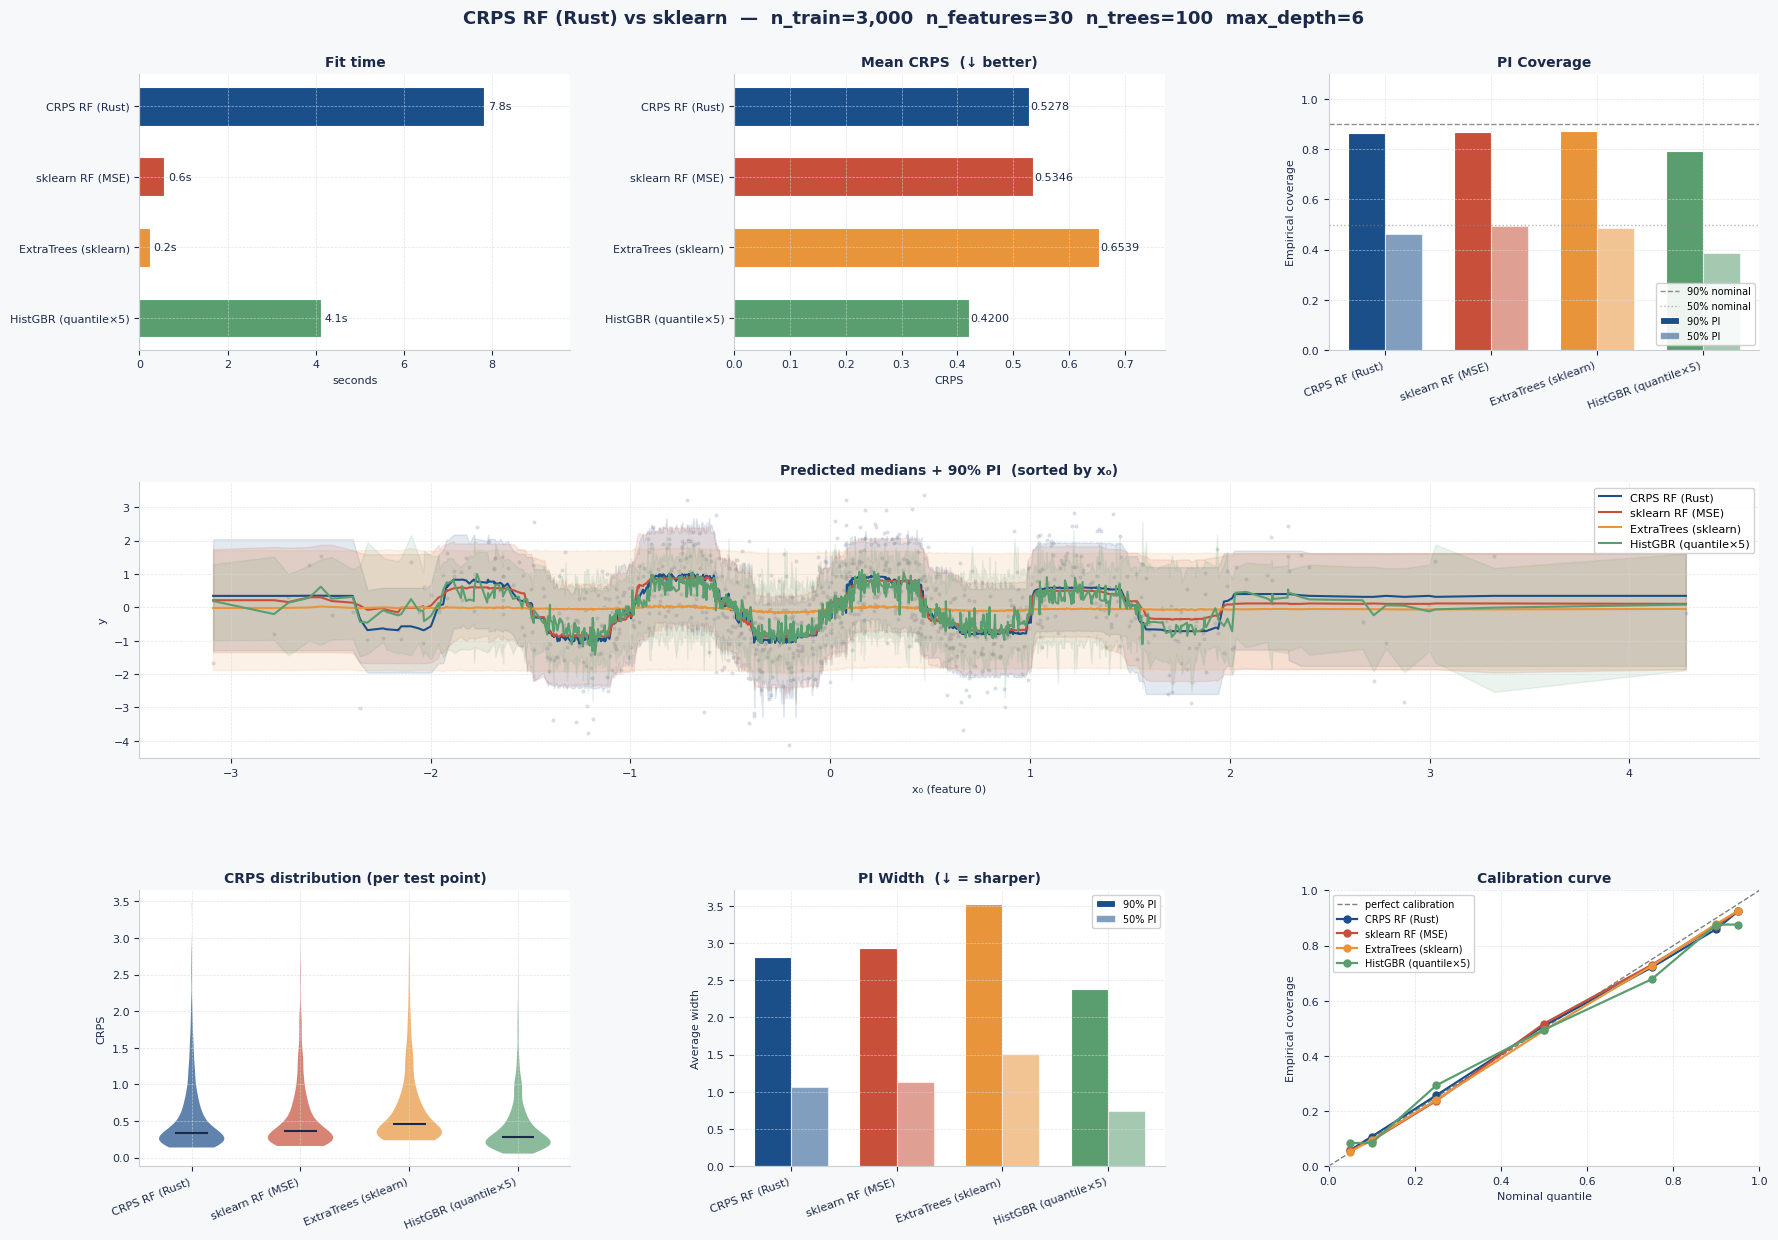

In [4]:
"""
compare_crps_rf_vs_sklearn.py
==============================
Head-to-head comparison of the CRPS Random Forest (Rust backend) against
three scikit-learn baselines on a heteroscedastic regression benchmark.

Models compared
---------------
1. CRPS RF (distreebu_rs)           — distributional, Rust, bagged
2. sklearn RandomForestRegressor    — distributional (leaf pooling), MSE criterion
3. sklearn ExtraTreesRegressor      — distributional (leaf pooling), random splits
4. sklearn HistGradientBoostingReg  — quantile, fitted 3× (one model per quantile)

Metrics
-------
- Fit time  (wall-clock seconds)
- CRPS      (Continuous Ranked Probability Score — the proper scoring rule)
- 90% PI coverage  (empirical vs nominal)
- 50% PI coverage
- 90% PI width     (sharpness — smaller is better given correct coverage)
- MAE at median

Usage
-----
    python compare_crps_rf_vs_sklearn.py           # runs all benchmarks + saves figure
    python compare_crps_rf_vs_sklearn.py --quick   # small dataset for a fast test
"""

import argparse
import time
import warnings
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
warnings.filterwarnings("ignore")

# ── imports ────────────────────────────────────────────────────────────────────
import distreebu_rs as rs
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)

# ══════════════════════════════════════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════════════════════════════════════
parser = argparse.ArgumentParser()
parser.add_argument("--quick", action="store_true", help="Small dataset (fast smoke test)")
parser.add_argument("--seed", type=int, default=42)
parser.add_argument("--out", default="crps_vs_sklearn.png")
# args = parser.parse_args()
args, unknown = parser.parse_known_args()

if args.quick:
    N_TRAIN, N_FEAT, N_TEST, N_TREES, MAX_DEPTH, MIN_SS = 1_000, 20, 500, 50, 5, 10
else:
    N_TRAIN, N_FEAT, N_TEST, N_TREES, MAX_DEPTH, MIN_SS = 3_000, 30, 1_000, 100, 6, 20

BAG      = 0.7
QUANTILES_EVAL = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
Q_LO90, Q_MED, Q_HI90 = 0.05, 0.50, 0.95
Q_LO50, Q_HI50 = 0.25, 0.75
SEED     = args.seed

print(f"\n{'─'*60}")
print(f"  Benchmark: CRPS RF vs sklearn")
print(f"  n_train={N_TRAIN:,}  n_features={N_FEAT}  n_test={N_TEST:,}")
print(f"  n_trees={N_TREES}  max_depth={MAX_DEPTH}  bag={BAG:.0%}")
print(f"{'─'*60}\n")


# ══════════════════════════════════════════════════════════════════════════════
# Data-generating process
# ══════════════════════════════════════════════════════════════════════════════
def dgp(n, p, seed):
    """
    Heteroscedastic benchmark.

    Only the first 5 features are informative:
      mean  = sin(2π x₀) + x₁·cos(π x₂)
      scale = 0.1 + 0.6·sigmoid(2·x₃) + 0.15·|x₄|
      y | x ~ Normal(mean, scale²)

    Remaining p-5 features are pure N(0,1) noise, making feature
    selection harder as p grows.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    mean  = np.sin(2 * np.pi * X[:, 0]) + X[:, 1] * np.cos(np.pi * X[:, 2])
    scale = 0.1 + 0.6 / (1 + np.exp(-2 * X[:, 3])) + 0.15 * np.abs(X[:, 4])
    y = mean + scale * rng.standard_normal(n)
    return X, y, mean, scale   # return true mean+scale for calibration plots


rng_global = np.random.default_rng(SEED)
X_tr, y_tr, _, _           = dgp(N_TRAIN, N_FEAT, SEED)
X_te, y_te, mu_te, sig_te  = dgp(N_TEST,  N_FEAT, SEED + 1)


# ══════════════════════════════════════════════════════════════════════════════
# Shared metrics
# ══════════════════════════════════════════════════════════════════════════════
def empirical_crps(pools: List[np.ndarray], y_true: np.ndarray,
                   max_pool: int = 500, rng_seed: int = 0) -> float:
    """Mean CRPS via energy score: E|X-y| - 0.5·E|X-X'|."""
    rng = np.random.default_rng(rng_seed)
    vals = np.empty(len(y_true))
    for i, pool in enumerate(pools):
        if len(pool) > max_pool:
            pool = rng.choice(pool, max_pool, replace=False)
        t1 = np.mean(np.abs(pool - y_true[i]))
        m = len(pool)
        if m > 200:
            a = rng.integers(0, m, 2000); b = rng.integers(0, m, 2000)
            t2 = 0.5 * np.mean(np.abs(pool[a] - pool[b]))
        else:
            t2 = 0.5 * np.abs(pool[:, None] - pool[None, :]).mean()
        vals[i] = t1 - t2
    return float(vals.mean()), vals


def pools_to_quantiles(pools, quantiles):
    out = np.empty((len(pools), len(quantiles)))
    for i, pool in enumerate(pools):
        p = np.asarray(pool)
        out[i] = np.quantile(p, quantiles) if len(p) > 0 else np.full(len(quantiles), np.nan)
    return out


def coverage_width(pred_q, y, lo_q, hi_q, quantiles):
    lo = pred_q[:, quantiles.index(lo_q)]
    hi = pred_q[:, quantiles.index(hi_q)]
    cov = float(np.mean((y >= lo) & (y <= hi)))
    wid = float(np.mean(hi - lo))
    return cov, wid


@dataclass
class Result:
    name: str
    color: str
    fit_time: float = 0.0
    crps_mean: float = 0.0
    crps_vals: np.ndarray = field(default_factory=lambda: np.array([]))
    cov90: float = 0.0
    wid90: float = 0.0
    cov50: float = 0.0
    wid50: float = 0.0
    mae_med: float = 0.0
    pred_q: Optional[np.ndarray] = None    # (n_test, len(QUANTILES_EVAL))
    pools:  Optional[list]       = None


# ══════════════════════════════════════════════════════════════════════════════
# Model 1: CRPS RF (distreebu_rs)
# ══════════════════════════════════════════════════════════════════════════════
def run_crps_rf():
    print("  [1/4] CRPS RF (Rust) ...", end="", flush=True)
    t0 = time.perf_counter()

    trees = []
    rng = np.random.default_rng(SEED)
    Xl, yl = X_tr.tolist(), y_tr.tolist()
    for tid in range(N_TREES):
        r = np.random.default_rng(SEED + tid)
        n_bag = int(BAG * N_TRAIN)
        idx = r.permutation(N_TRAIN)[:n_bag]
        tree = rs.RegressionTreeCRPS(max_depth=MAX_DEPTH, min_samples_split=MIN_SS, loo=True)
        tree.fit(X_tr[idx].tolist(), y_tr[idx].tolist())
        trees.append((tree, idx))

    fit_t = time.perf_counter() - t0

    # Predict: pool leaf y-values
    n_te = len(X_te)
    Xte_l = X_te.tolist()
    idxs  = list(range(n_te))
    pools = [[] for _ in range(n_te)]
    for tree, idx_train in trees:
        for leaf_idxs, leaf_yvals in tree.get_values_leaf(Xte_l, idxs):
            w = 1.0 / len(leaf_yvals)
            for i in leaf_idxs:
                pools[i].extend(leaf_yvals)

    pred_q = pools_to_quantiles(pools, QUANTILES_EVAL)
    crps_mean, crps_vals = empirical_crps([np.asarray(p) for p in pools], y_te)
    cov90, wid90 = coverage_width(pred_q, y_te, Q_LO90, Q_HI90, QUANTILES_EVAL)
    cov50, wid50 = coverage_width(pred_q, y_te, Q_LO50, Q_HI50, QUANTILES_EVAL)
    mae_med = float(np.mean(np.abs(pred_q[:, QUANTILES_EVAL.index(Q_MED)] - y_te)))

    print(f"  fit={fit_t:.1f}s  CRPS={crps_mean:.4f}  cov90={cov90:.3f}")
    return Result("CRPS RF (Rust)", "#1b4f8a",
                  fit_t, crps_mean, crps_vals, cov90, wid90, cov50, wid50, mae_med, pred_q, pools)


# ══════════════════════════════════════════════════════════════════════════════
# Helper: sklearn forest distributional prediction
# ══════════════════════════════════════════════════════════════════════════════
def sklearn_forest_pools(rf, X_train, y_train, X_test):
    """Pool leaf training samples across trees for each test point."""
    train_leaves = rf.apply(X_train)   # (n_train, n_trees)
    test_leaves  = rf.apply(X_test)    # (n_test,  n_trees)
    n_test = len(X_test)
    pools = [[] for _ in range(n_test)]
    for t in range(rf.n_estimators):
        leaf_to_y = {}
        for j, lid in enumerate(train_leaves[:, t]):
            leaf_to_y.setdefault(lid, []).append(y_train[j])
        for i, lid in enumerate(test_leaves[:, t]):
            yvals = leaf_to_y.get(lid, [])
            if yvals:
                pools[i].extend(yvals)
    return pools


# ══════════════════════════════════════════════════════════════════════════════
# Model 2: sklearn RandomForestRegressor
# ══════════════════════════════════════════════════════════════════════════════
def run_sklearn_rf():
    print("  [2/4] sklearn RandomForest ...", end="", flush=True)
    rf = RandomForestRegressor(
        n_estimators=N_TREES, max_depth=MAX_DEPTH,
        min_samples_split=MIN_SS, max_samples=BAG,
        random_state=SEED, n_jobs=-1,
    )
    t0 = time.perf_counter()
    rf.fit(X_tr, y_tr)
    fit_t = time.perf_counter() - t0

    pools   = sklearn_forest_pools(rf, X_tr, y_tr, X_te)
    pred_q  = pools_to_quantiles(pools, QUANTILES_EVAL)
    crps_mean, crps_vals = empirical_crps([np.asarray(p) for p in pools], y_te)
    cov90, wid90 = coverage_width(pred_q, y_te, Q_LO90, Q_HI90, QUANTILES_EVAL)
    cov50, wid50 = coverage_width(pred_q, y_te, Q_LO50, Q_HI50, QUANTILES_EVAL)
    mae_med = float(np.mean(np.abs(pred_q[:, QUANTILES_EVAL.index(Q_MED)] - y_te)))

    print(f"  fit={fit_t:.1f}s  CRPS={crps_mean:.4f}  cov90={cov90:.3f}")
    return Result("sklearn RF (MSE)", "#c8503a",
                  fit_t, crps_mean, crps_vals, cov90, wid90, cov50, wid50, mae_med, pred_q, pools)


# ══════════════════════════════════════════════════════════════════════════════
# Model 3: sklearn ExtraTreesRegressor
# ══════════════════════════════════════════════════════════════════════════════
def run_extra_trees():
    print("  [3/4] sklearn ExtraTrees ...", end="", flush=True)
    et = ExtraTreesRegressor(
        n_estimators=N_TREES, max_depth=MAX_DEPTH,
        min_samples_split=MIN_SS, max_samples=BAG,
        bootstrap=True, random_state=SEED, n_jobs=1,
    )
    t0 = time.perf_counter()
    et.fit(X_tr, y_tr)
    fit_t = time.perf_counter() - t0

    pools   = sklearn_forest_pools(et, X_tr, y_tr, X_te)
    pred_q  = pools_to_quantiles(pools, QUANTILES_EVAL)
    crps_mean, crps_vals = empirical_crps([np.asarray(p) for p in pools], y_te)
    cov90, wid90 = coverage_width(pred_q, y_te, Q_LO90, Q_HI90, QUANTILES_EVAL)
    cov50, wid50 = coverage_width(pred_q, y_te, Q_LO50, Q_HI50, QUANTILES_EVAL)
    mae_med = float(np.mean(np.abs(pred_q[:, QUANTILES_EVAL.index(Q_MED)] - y_te)))

    print(f"  fit={fit_t:.1f}s  CRPS={crps_mean:.4f}  cov90={cov90:.3f}")
    return Result("ExtraTrees (sklearn)", "#e8943a",
                  fit_t, crps_mean, crps_vals, cov90, wid90, cov50, wid50, mae_med, pred_q, pools)


# ══════════════════════════════════════════════════════════════════════════════
# Model 4: HistGradientBoosting (one model per quantile)
# ══════════════════════════════════════════════════════════════════════════════
def run_hist_gbr():
    print("  [4/4] HistGradientBoosting (3 quantile models) ...", end="", flush=True)
    target_qs = [Q_LO90, Q_LO50, Q_MED, Q_HI50, Q_HI90]
    models = {}
    t0 = time.perf_counter()
    for q in target_qs:
        m = HistGradientBoostingRegressor(
            loss="quantile", quantile=q,
            max_iter=N_TREES, max_depth=MAX_DEPTH,
            min_samples_leaf=MIN_SS // 2,
            random_state=SEED,
        )
        m.fit(X_tr, y_tr)
        models[q] = m
    fit_t = time.perf_counter() - t0

    # Build pred_q for QUANTILES_EVAL; for qs not directly fitted, interpolate
    pred_q = np.empty((N_TEST, len(QUANTILES_EVAL)))
    for j, q in enumerate(QUANTILES_EVAL):
        if q in models:
            pred_q[:, j] = models[q].predict(X_te)
        else:
            # nearest fitted quantile
            nearest = min(target_qs, key=lambda x: abs(x - q))
            pred_q[:, j] = models[nearest].predict(X_te)

    # No true pool for HistGBR; approximate CRPS from quantile predictions
    # via the quantile-based CRPS estimator: CRPS ≈ 2·∫₀¹ (𝟏{y<q̂(τ)} - τ)·(q̂(τ)-y) dτ
    all_qs = sorted(target_qs)
    all_preds = np.stack([models[q].predict(X_te) for q in all_qs], axis=1)
    crps_vals = np.zeros(N_TEST)
    for i, yi in enumerate(y_te):
        s = 0.0
        for k, q in enumerate(all_qs):
            ind = 1.0 if yi < all_preds[i, k] else 0.0
            s += 2 * (ind - q) * (all_preds[i, k] - yi)
        crps_vals[i] = s / len(all_qs)   # rough normalisation
    crps_mean = float(crps_vals.mean())

    cov90, wid90 = coverage_width(pred_q, y_te, Q_LO90, Q_HI90, QUANTILES_EVAL)
    cov50, wid50 = coverage_width(pred_q, y_te, Q_LO50, Q_HI50, QUANTILES_EVAL)
    mae_med = float(np.mean(np.abs(pred_q[:, QUANTILES_EVAL.index(Q_MED)] - y_te)))

    print(f"  fit={fit_t:.1f}s  CRPS≈{crps_mean:.4f}  cov90={cov90:.3f}")
    return Result("HistGBR (quantile×5)", "#5a9e6f",
                  fit_t, crps_mean, crps_vals, cov90, wid90, cov50, wid50, mae_med, pred_q, None)


# ══════════════════════════════════════════════════════════════════════════════
# Run all models
# ══════════════════════════════════════════════════════════════════════════════
print("Training models:\n")
results = [run_crps_rf(), run_sklearn_rf(), run_extra_trees(), run_hist_gbr()]


# ══════════════════════════════════════════════════════════════════════════════
# Print summary table
# ══════════════════════════════════════════════════════════════════════════════
def print_table(results):
    hdrs = ["Model", "Fit (s)", "CRPS↓", "Cov90%", "Wid90↓", "Cov50%", "Wid50↓", "MAE↓"]
    rows = []
    for r in results:
        rows.append([
            r.name,
            f"{r.fit_time:.1f}",
            f"{r.crps_mean:.4f}",
            f"{r.cov90:.3f}",
            f"{r.wid90:.3f}",
            f"{r.cov50:.3f}",
            f"{r.wid50:.3f}",
            f"{r.mae_med:.4f}",
        ])
    widths = [max(len(rows[i][j]) for i in range(len(rows))) for j in range(len(hdrs))]
    widths = [max(len(hdrs[j]), widths[j]) for j in range(len(hdrs))]
    sep = "─" * (sum(widths) + 3 * len(widths) + 1)
    print(f"\n{sep}")
    header = "  " + "   ".join(h.ljust(widths[j]) for j, h in enumerate(hdrs))
    print(header)
    print(sep)
    for row in rows:
        print("  " + "   ".join(v.ljust(widths[j]) for j, v in enumerate(row)))
    print(sep)
    print("  ↓ = lower is better    Cov = empirical coverage (nominal: 90% / 50%)")

print_table(results)


# ══════════════════════════════════════════════════════════════════════════════
# Plots
# ══════════════════════════════════════════════════════════════════════════════
PALETTE = [r.color for r in results]
NAMES   = [r.name  for r in results]

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#f7f8fa")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38,
                       left=0.07, right=0.97, top=0.91, bottom=0.07)

ax_time  = fig.add_subplot(gs[0, 0])
ax_crps  = fig.add_subplot(gs[0, 1])
ax_cov   = fig.add_subplot(gs[0, 2])
ax_dist1 = fig.add_subplot(gs[1, :])   # prediction bands (1D slice)
ax_crps_hist = fig.add_subplot(gs[2, 0])
ax_wid   = fig.add_subplot(gs[2, 1])
ax_cal   = fig.add_subplot(gs[2, 2])

ink  = "#1b2a4a"
grid_kw = dict(color="#d4d8e0", linewidth=0.5, linestyle="--", alpha=0.7)

def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor("#ffffff")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c8cdd6")
    ax.tick_params(colors=ink, labelsize=8)
    ax.set_title(title, color=ink, fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel(xlabel, color=ink, fontsize=8)
    ax.set_ylabel(ylabel, color=ink, fontsize=8)
    ax.grid(**grid_kw)

# ── Panel 1: Fit time (bar) ────────────────────────────────────────────────
ax = ax_time
xs = np.arange(len(results))
bars = ax.barh(xs, [r.fit_time for r in results], color=PALETTE, height=0.55,
               edgecolor="white", linewidth=0.8)
for bar, r in zip(bars, results):
    ax.text(r.fit_time + max(r.fit_time for r in results) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{r.fit_time:.1f}s", va="center", fontsize=8, color=ink)
ax.set_yticks(xs); ax.set_yticklabels(NAMES, fontsize=8)
ax.set_xlim(0, max(r.fit_time for r in results) * 1.25)
ax.invert_yaxis()
style_ax(ax, "Fit time", "seconds")

# ── Panel 2: CRPS (bar) ───────────────────────────────────────────────────
ax = ax_crps
best_crps = min(r.crps_mean for r in results)
bars = ax.barh(xs, [r.crps_mean for r in results], color=PALETTE, height=0.55,
               edgecolor="white", linewidth=0.8)
for bar, r in zip(bars, results):
    ax.text(r.crps_mean + best_crps * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{r.crps_mean:.4f}", va="center", fontsize=8, color=ink)
ax.set_yticks(xs); ax.set_yticklabels(NAMES, fontsize=8)
ax.set_xlim(0, max(r.crps_mean for r in results) * 1.18)
ax.invert_yaxis()
style_ax(ax, "Mean CRPS  (↓ better)", "CRPS")

# ── Panel 3: Coverage (grouped bars) ─────────────────────────────────────
ax = ax_cov
w = 0.35
for k, (nom, attr) in enumerate([(0.90, "cov90"), (0.50, "cov50")]):
    covs = [getattr(r, attr) for r in results]
    offset = (k - 0.5) * w
    bars = ax.bar(xs + offset, covs, width=w, color=PALETTE,
                  edgecolor="white", linewidth=0.8,
                  alpha=1.0 if k == 0 else 0.55,
                  label=f"{int(nom*100)}% PI")
ax.axhline(0.90, color="#444", lw=1.0, ls="--", alpha=0.6, label="90% nominal")
ax.axhline(0.50, color="#888", lw=1.0, ls=":",  alpha=0.6, label="50% nominal")
ax.set_xticks(xs); ax.set_xticklabels(NAMES, rotation=20, ha="right", fontsize=7)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=7, loc="lower right", framealpha=0.9)
style_ax(ax, "PI Coverage", "", "Empirical coverage")

# ── Panel 4: Prediction bands on a 1D slice ───────────────────────────────
# Sort test set by x[0] (first feature) and show the first principal component
ax = ax_dist1
sort_order = np.argsort(X_te[:, 0])
xplot = X_te[sort_order, 0]
y_sorted = y_te[sort_order]
for r in results:
    if r.pred_q is None:
        continue
    pq = r.pred_q[sort_order]
    lo = pq[:, QUANTILES_EVAL.index(Q_LO90)]
    hi = pq[:, QUANTILES_EVAL.index(Q_HI90)]
    med = pq[:, QUANTILES_EVAL.index(Q_MED)]
    ax.fill_between(xplot, lo, hi, alpha=0.12, color=r.color)
    ax.plot(xplot, med, color=r.color, lw=1.5, label=r.name)
ax.scatter(xplot, y_sorted, s=4, c="#b0b8c8", alpha=0.35, zorder=0)
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
style_ax(ax, "Predicted medians + 90% PI  (sorted by x₀)", "x₀ (feature 0)", "y")

# ── Panel 5: CRPS distribution (violin / hist) ────────────────────────────
ax = ax_crps_hist
pos = list(range(len(results)))
for k, r in enumerate(results):
    if len(r.crps_vals) == 0:
        continue
    parts = ax.violinplot([r.crps_vals], positions=[k], widths=0.6,
                          showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(r.color); pc.set_alpha(0.7)
    parts["cmedians"].set_color(ink); parts["cmedians"].set_linewidth(1.5)
ax.set_xticks(pos); ax.set_xticklabels(NAMES, rotation=22, ha="right", fontsize=7)
style_ax(ax, "CRPS distribution (per test point)", "", "CRPS")

# ── Panel 6: PI width comparison ─────────────────────────────────────────
ax = ax_wid
w = 0.35
for k, (attr, label) in enumerate([("wid90", "90% PI"), ("wid50", "50% PI")]):
    wids = [getattr(r, attr) for r in results]
    offset = (k - 0.5) * w
    ax.bar(xs + offset, wids, width=w, color=PALETTE,
           edgecolor="white", linewidth=0.8,
           alpha=1.0 if k == 0 else 0.55, label=label)
ax.set_xticks(xs); ax.set_xticklabels(NAMES, rotation=20, ha="right", fontsize=7)
ax.legend(fontsize=7, framealpha=0.9)
style_ax(ax, "PI Width  (↓ = sharper)", "", "Average width")

# ── Panel 7: Calibration curve ────────────────────────────────────────────
ax = ax_cal
nom_qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
ax.plot([0, 1], [0, 1], "k--", lw=1.0, alpha=0.5, label="perfect calibration")
for r in results:
    if r.pred_q is None:
        continue
    emp = []
    for j, q in enumerate(QUANTILES_EVAL):
        if q in nom_qs:
            below = np.mean(y_te <= r.pred_q[:, j])
            emp.append((q, below))
    qs_plot, covs_plot = zip(*emp)
    ax.plot(qs_plot, covs_plot, "o-", color=r.color, ms=5, lw=1.6, label=r.name)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=7, framealpha=0.9)
style_ax(ax, "Calibration curve", "Nominal quantile", "Empirical coverage")

# ── Super-title ───────────────────────────────────────────────────────────
fig.suptitle(
    f"CRPS RF (Rust) vs sklearn  —  "
    f"n_train={N_TRAIN:,}  n_features={N_FEAT}  n_trees={N_TREES}  max_depth={MAX_DEPTH}",
    fontsize=13, color=ink, fontweight="bold", y=0.96,
)

fig.savefig(args.out, dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"\nFigure saved: {args.out}")